In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re
import ast 

## 1ere section : analyse du dataset (arxiv)

à l'issue de ce notebook nous aurons l'occasion de parcourir ce dataset, de traiter l'étendu des données le constituant (données textuelles précisèment), les transformer et appliquer un problème de ML dessus

le dataset : arXiv paper abstract dataset for building multi-label text classifiers. // https://www.kaggle.com/datasets/spsayakpaul/arxiv-paper-abstracts/data 


In [2]:
def charger_dataset(chemin_dataset : str = "./data/arxiv_data.csv"):
    #chemin par défaut renvoie au dataset avec abstract 
    return pd.read_csv(chemin_dataset)

df = charger_dataset()
df.describe()

,titles,summaries,terms
count,51774,51774,51774
unique,38972,38979,3157
top,Transformers in Vision: A Survey,Astounding results from Transformer models on ...,['cs.CV']
freq,7,7,17369


### Analyse des données du dataset 

Nombre total de documents : 51774
Colonnes disponibles : ['titles', 'summaries', 'terms']
Valeurs manquantes par colonne :
titles       0
summaries    0
terms        0
dtype: int64
Nombre de catégories uniques : 3157
Distribution des catégories (top 10) :
terms
['cs.CV']                        17369
['cs.LG', 'stat.ML']              5251
['cs.LG']                         2732
['cs.CV', 'cs.LG']                2067
['cs.LG', 'cs.AI']                1702
['cs.LG', 'cs.AI', 'stat.ML']     1470
['stat.ML', 'cs.LG']              1376
['cs.CV', 'cs.AI']                 939
['cs.CV', 'cs.LG', 'eess.IV']      855
['cs.CV', 'eess.IV']               769
Name: count, dtype: int64
nombre réel de catégories unique :  1099  => catégories : 
  {'I.4.8; I.4.10', '68N20', 'I.2.6; H.4.0', 'I.2.11; H.1.1', 'cs.DS', 'I.2.10; I.4.8; I.4.9; I.4.10; I.5.4; K.4.4', 'I.4.0', 'I.2.0; I.2.6', '68W15', 'I.4.8; I.4.9; I.2.10', '93', '16G20', 'math.LO', 'I.2.6; I.2.10; I.2.1', 'cs.DM', 'G.3; I.2.4; I.2.6', '68T42',

Text(0, 0.5, 'Nombre de documents')

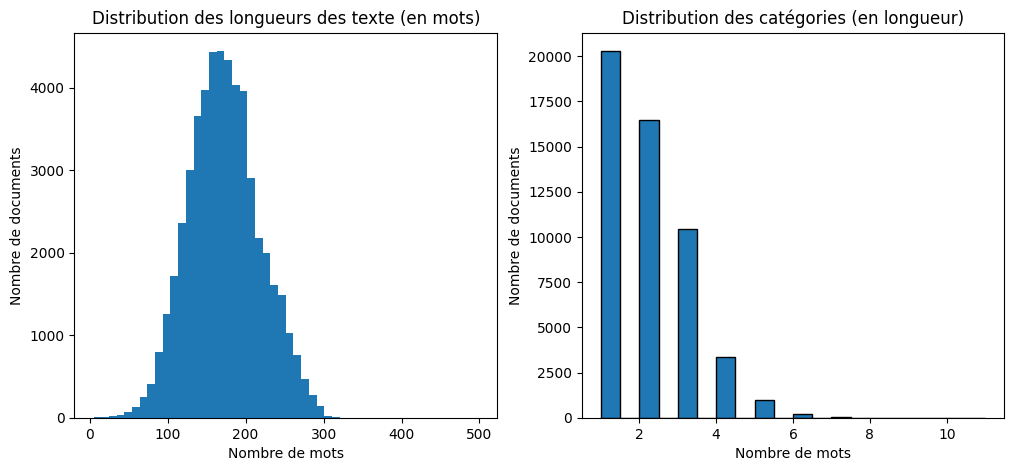

In [3]:
num_documents = df.shape[0]
print(f"Nombre total de documents : {num_documents}")

colonnes = df.columns.tolist()
print(f"Colonnes disponibles : {colonnes}")

valeurs_manquantes = df.isnull().sum()
print("Valeurs manquantes par colonne :")
print(valeurs_manquantes)

colonne_categories = 'terms'  
colonnes_texte = 'summaries'  

### Region 1 : analyse des catégories : terms 


num_categories = df[colonne_categories].nunique()
print(f"Nombre de catégories uniques : {num_categories}")

distribution_categories = df[colonne_categories].value_counts()
print("Distribution des catégories (top 10) :")
print(distribution_categories.head(10))



ensemble_categories = set()
for categories_str in df[colonne_categories]:
    #convertir la chaine et liste 
    categories_list = ast.literal_eval(categories_str) 
    ensemble_categories.update(categories_list)
        

print("nombre réel de catégories unique : ",len(ensemble_categories)," => catégories : \n ",ensemble_categories)

df["longueur_categories"] = df[colonne_categories].apply(lambda x : len(ast.literal_eval(x)))
moyenne_labels_par_doc = df["longueur_categories"].mean()
max_labels_par_doc = df["longueur_categories"].max()
print(f"Nombre moyen de labels par document : {moyenne_labels_par_doc}")
print(f"Nombre maximum de labels par document : {max_labels_par_doc}")


## 2 : analyse de la colonne texte  

df["longueur_texte"] = df[colonnes_texte].astype(str).str.split().apply(len)
longueur_moyenne = df["longueur_texte"].mean()
longueur_mediane = df["longueur_texte"].median()
longueur_min = df["longueur_texte"].min()
longueur_max = df["longueur_texte"].max()
print(f"Longueur moyenne des abstracts (mots) : {longueur_moyenne}")
print(f"Longueur médiane des abstracts (mots) : {longueur_mediane}")
print(f"Longueur minimale : {longueur_min}, maximale : {longueur_max}")
 
 
fig, graphiques = plt.subplots(1, 2, figsize=(12, 5))
graphiques[0].hist(df["longueur_texte"], bins=50)
graphiques[0].set_title('Distribution des longueurs des texte (en mots)')
graphiques[0].set_xlabel('Nombre de mots')
graphiques[0].set_ylabel('Nombre de documents')

graphiques[1].hist(df["longueur_categories"], bins=20, edgecolor='black')
graphiques[1].set_title('Distribution des catégories (en longueur)')
graphiques[1].set_xlabel('Nombre de mots')
graphiques[1].set_ylabel('Nombre de documents')


# #présence de doublons .. .suppression au niveau de summaries 
# doublons_summaries = df[df.duplicated(subset=["title","summaries"], keep=False)]
# print("\nExemples de doublons sur summaries (premiers 5) :")
# print(doublons_summaries[["titles", "summaries", "terms"]].head(5))


première analyse à chaud : difficultés quant au nombre de catégories distinctes 1099 => à voir si on en garde que les top-k plus fréquentes ? 

MultiLabelClassification ? avec seuillage sur une sigmoide à la fin (ou garder softmax sur une seule sortie seuleemnt parmi plusieurs labels ???) 

Stratégie : oneVsRest/ All , classe CS et le reste .... et ensuite physique et le reste (y compris CS ...) ??? wrapper autour d'un classifier offert par scikit 
mais on traite pas les similarités entre catégories ??? car nous supposons que les labels sont indépendants, optimisation en ajoutant les prédictions dans les features si jamais ??? à explorer le classifierChain ? 
p(X)=ML , seconde préd P(X+ML)= CV ? 



In [4]:
df = df.drop_duplicates(subset=["titles","summaries"]).reset_index(drop=True)
df.shape

(38985, 5)

### Comptage de classes avant création nouveaux labels

In [5]:
from collections import Counter

def comptage_categories(colonne : str , top_k = 20) : 
    categories_uniques = []
    if colonne == colonne_categories : 
        for categories_str in df[colonne]:
            categories_liste = ast.literal_eval(categories_str)
            categories_uniques.extend(categories_liste)  
    elif colonne == "categories_a_garder":
        for categorie in df[colonne]:
            categories_uniques.extend(categorie) 
    else : #elt unique
        categories_uniques = df[colonne]
    categories_compteurs = Counter(categories_uniques)

    top_k_categories = categories_compteurs.most_common(top_k)

    set_temporaire = set()
    print(f"Top {top_k} catégories (par fréquence) :")
    for categorie , count in top_k_categories:
        print(f"{categorie} ==> : {count}")
        set_temporaire.add(categorie)
    return list(set_temporaire)
        
        

liste_topk = comptage_categories(colonne_categories)

print(liste_topk)


Top 20 catégories (par fréquence) :
cs.CV ==> : 22262
cs.LG ==> : 22247
stat.ML ==> : 12429
cs.AI ==> : 5951
eess.IV ==> : 1763
cs.RO ==> : 1493
cs.CL ==> : 1096
cs.NE ==> : 1014
cs.CR ==> : 590
math.OC ==> : 583
eess.SP ==> : 481
cs.GR ==> : 446
cs.SI ==> : 430
cs.SY ==> : 387
cs.MM ==> : 385
cs.IR ==> : 351
cs.MA ==> : 304
eess.SY ==> : 297
cs.HC ==> : 279
cs.IT ==> : 242
['cs.GR', 'cs.MM', 'cs.SI', 'cs.SY', 'cs.IR', 'cs.CL', 'cs.AI', 'cs.MA', 'cs.CR', 'cs.RO', 'cs.IT', 'cs.NE', 'cs.HC', 'cs.CV', 'cs.LG', 'eess.IV', 'eess.SY', 'stat.ML', 'eess.SP', 'math.OC']


cv : computer vison and pattern recognition 

lg : machihne learning aspects 

stats.ml : orientation statistique 

ai :systèmes experts , ia symbolique 

eess.iv : image video processing

ro : robotics 

cl : computation and language

ne : neural and evolutionary computing

cr : cryptography and security

sp : signal processing

gr : graphics

IR : information retrieval


In [6]:
## Création nouveaux labels 
"""idée : garder premier élement de la liste pour l'instant"""
def get_premier_element_liste_categorie(liste_str : str) -> str : 
    liste_converti = ast.literal_eval(liste_str)
    return liste_converti[0]

# df["categories_reduites"] = df[colonne_categories].apply(get_premier_element_liste_categorie)


### refaire le comptage en ayant gardé premier élement de la liste de categories

In [7]:
# nouvelle_colonne_categories = 'categories_reduites'
# comptage_categories(colonne=nouvelle_colonne_categories)


résultat : perte d'information énorme, solution garder que les labels appartenant au top 20 dans la liste et faire de la classification multi label

remarqye : classification sur nouvelle classe "categories_a_garder"

In [8]:
def keep_top20_categories_dans_liste(liste_str : str , liste_topk = liste_topk) -> str : 
    liste_convertie = ast.literal_eval(liste_str)
    l_finale = [l for l in liste_convertie if l in liste_topk]
    return l_finale

df["categories_a_garder"] = df[colonne_categories].apply(keep_top20_categories_dans_liste)
comptage_categories("categories_a_garder",40) # Vérifier que top20 bien appliqué 

df.to_csv("data/df_processed.csv", index=False)

Top 40 catégories (par fréquence) :
cs.CV ==> : 22262
cs.LG ==> : 22247
stat.ML ==> : 12429
cs.AI ==> : 5951
eess.IV ==> : 1763
cs.RO ==> : 1493
cs.CL ==> : 1096
cs.NE ==> : 1014
cs.CR ==> : 590
math.OC ==> : 583
eess.SP ==> : 481
cs.GR ==> : 446
cs.SI ==> : 430
cs.SY ==> : 387
cs.MM ==> : 385
cs.IR ==> : 351
cs.MA ==> : 304
eess.SY ==> : 297
cs.HC ==> : 279
cs.IT ==> : 242


## 2. Traitement et Transformation du Texte

Dans cette section, nous allons explorer les techniques de traitement du texte en utilisant scikit-learn, en suivant le tutoriel officiel : https://scikit-learn.org/stable/tutorial/text_analytics/working_with_text_data.html#tutorial-setup

Nous allons appliquer ces techniques sur notre dataset arXiv pour extraire des caractéristiques numériques des textes.

In [9]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import normalize
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import download as telechargement_nltk

telechargement_nltk('punkt_tab')
telechargement_nltk('stopwords')
telechargement_nltk('wordnet')
telechargement_nltk('omw-1.4')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\mokht\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mokht\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\mokht\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\mokht\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

### A. Extraction de caractéristiques à partir de fichiers texte - Sacs de mots (Bags of Words)

Le moyen le plus intuitif de transformer le texte en vecteur est d'utiliser une représentation en sacs de mots :

1. Attribuer un identifiant entier fixe à chaque mot apparaissant dans n'importe quel document de l'ensemble d'entraînement (par exemple en construisant un dictionnaire de mots vers indices entiers).
2. Pour chaque document #i, compter le nombre d'occurrences de chaque mot w et le stocker dans X[i, j] comme valeur de la caractéristique #j où j est l'index du mot w dans le dictionnaire.

Cette approche ignore l'ordre des mots et se concentre uniquement sur leur fréquence.

In [10]:
MAX_FEATURES = 5000 ; MIN_DF = 100 ; MAX_DF = 0.8
configuration_vectorizer = {"max_features":MAX_FEATURES,"stop_words":"english","min_df":MIN_DF,"max_df":MAX_DF,"lowercase":True}
count_vectorizer = CountVectorizer(**configuration_vectorizer)

print("\n--- Lancement du vectorizer sur dataset arxiv (summariess) ---")
summaries_liste = df['summaries'].tolist()

X_arxiv_summaries = count_vectorizer.fit_transform(summaries_liste)
print("Vocabulaire taille finale du dataset:", len(count_vectorizer.get_feature_names_out()))
print("matrice finale forme:", X_arxiv_summaries.shape)
print("Exemple de caractéristiques pour le premier document:")




--- Lancement du vectorizer sur dataset arxiv (summariess) ---
Vocabulaire taille finale du dataset: 3632
matrice finale forme: (38985, 3632)
Exemple de caractéristiques pour le premier document:


### Remarque : 
avec une configuration de base injectée dans le vectorizer : on se retrouve avec un vocabulaire de 12368

min_df = 10 : nombre occurence minimal des mots est de 10 dans tout le corpus 
max_df 0.8 : si trop fréquent alors dans ce cas on se retrouve avec des mots trop fréquents dans ce cas alors on dévide de pas traiter ces mots ( comme paper ....)

### C. Prétraitement avec Lemmatisation, Stemmatisation et autres techniques

Le prétraitement avancé du texte va au-delà de la simple tokenisation et du filtrage des mots vides. Nous allons explorer plusieurs techniques importantes :

stemming lemmatisation, etc ... puis comme résultat final on va faire notre fonction de prétraitement, et comparer taille de la matrice à la fin du vectorizer dans les deux cas avec la même configuration. 

In [11]:
import re
from typing import Literal


def preprocess_texte(texte:str,strategie:Literal["stemmer","lemmatizer"]="lemmatizer") -> str:
    texte = texte.lower().strip()
    texte = re.sub(r'[^\w\s]', '', texte)#gardons seulement lettre chiffre et espace
    tokens = word_tokenize(texte) #premiere tokenization
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words and len(token)>=2 and not token.isdigit()]
    if strategie == "stemmer":
        stemmer_objet = PorterStemmer()
        liste_tokens_propres =  [stemmer_objet.stem(token) for token in tokens]
    elif strategie == "lemmatizer":
        lemmatizer_objet = WordNetLemmatizer()
        liste_tokens_propres =  [lemmatizer_objet.lemmatize(token) for token in tokens]
    else  :
        raise NotImplementedError("pas d'implémentation sur autre approchess")
        liste_tokens_propres = []
    
    if liste_tokens_propres is not None : 
        return " ".join(liste_tokens_propres)
    

#test de la méthode 

texte_random = "there is nothing that can handle this paper i can't even imagine"
texte_cleaned = preprocess_texte(texte_random)
print("texte_cleand : " , texte_cleaned)


# df["summaries_nettoye"]= df["summaries"].apply(preprocess_texte)

texte_cleand :  nothing handle paper cant even imagine


In [12]:
""" application du vectorizer directement """
df["summaries_nettoye"]=df["summaries"].apply(preprocess_texte)
summaries_cleaned_liste = df["summaries_nettoye"].tolist()
X_arxiv_summaries_nettoye = count_vectorizer.fit_transform(summaries_cleaned_liste)
print("Vocabulaire taille finale du dataset:", len(count_vectorizer.get_feature_names_out()))
print("matrice finale forme:", X_arxiv_summaries_nettoye.shape)
print("Exemple de caractéristiques pour le premier document:")

Vocabulaire taille finale du dataset: 3149
matrice finale forme: (38985, 3149)
Exemple de caractéristiques pour le premier document:


### Observation : 
pas de changement majeur sur la taille du vocabulaire .... 

In [13]:
tfidf_vectorizer = TfidfVectorizer(**configuration_vectorizer)

def vectorizer_simple(liste : str , vectorizer_type:Literal["countVectorizer","tfidfVectorizer"]="countVectorizer"): 
    if vectorizer_type == "countVectorizer" : 
        X_arxiv_summaries_nettoye = count_vectorizer.fit_transform(liste)
        print("Vocabulaire taille finale du dataset:", len(count_vectorizer.get_feature_names_out()))
        print("matrice finale forme:", X_arxiv_summaries_nettoye.shape)
    elif vectorizer_type == "tfidfVectorizer" : 
        X_arxiv_summaries_nettoye = tfidf_vectorizer.fit_transform(liste)
        vocabulaire = tfidf_vectorizer.get_feature_names_out()
        idf_scores = tfidf_vectorizer.idf_
        top_terms = sorted(zip(vocabulaire, idf_scores), key=lambda x: x[1], reverse=True)[:10]
        print("-- affichage des termes -- :")
        for term, idf in top_terms:
            print(f"    {term}: {idf}")
        print("matrice finale forme:", X_arxiv_summaries_nettoye.shape)
        X_arxiv_summaries_nettoye = normalize(X_arxiv_summaries_nettoye, norm='l2')
    return X_arxiv_summaries_nettoye

PHRASES_DOCUMENT_NETTOYEES = df["summaries_nettoye"].tolist()

liste_vectorizer_tf_idf = vectorizer_simple(PHRASES_DOCUMENT_NETTOYEES,"tfidfVectorizer")

-- affichage des termes -- :
    assigns: 6.955837369464831
    atom: 6.955837369464831
    circumvent: 6.955837369464831
    default: 6.955837369464831
    disjoint: 6.955837369464831
    ecommerce: 6.955837369464831
    eigenvalue: 6.955837369464831
    emerge: 6.955837369464831
    examination: 6.955837369464831
    formalism: 6.955837369464831
matrice finale forme: (38985, 3149)


### Entrainement doc2Vec

Documentation de l'api : https://radimrehurek.com/gensim/models/doc2vec.html

hypothèse : on traite les summaries ici comme des documents et la finalité ce sera donc de comparer directement l'approche avec du word2Vec , Glove et les sentenceTransformers ...

In [24]:
from gensim.models.doc2vec import Doc2Vec , TaggedDocument
from gensim.test.utils import get_tmpfile #pour poursuivre entrainement sur modèle loaded  si ça se finit pas ??? 

import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO) #pour epochs dans training



documents_tagges = [TaggedDocument(doc.split(),[f"doc_{i}"]) for i,doc in enumerate(PHRASES_DOCUMENT_NETTOYEES)]

doc2vec_conf = {"vector_size":300,"window":5,"min_count":5,"workers":16,"dm":0,"epochs":50} # 1 moins bon pour les mots rares test avec dm = 0  équivalent skip gram

doc2vec_modele = Doc2Vec(**doc2vec_conf)#pv-dm en mettant  = 1

doc2vec_modele.build_vocab(documents_tagges) #prépare modele pour entrainement , word frequency ...
print(f"vocabulaire : {len(doc2vec_modele.wv)} mots")

doc2vec_modele.train(documents_tagges, total_examples=doc2vec_modele.corpus_count, epochs=doc2vec_modele.epochs)


2026-04-16 02:09:24,480 : INFO : Doc2Vec lifecycle event {'params': 'Doc2Vec<dbow,d300,n5,mc5,s0.001,t16>', 'datetime': '2026-04-16T02:09:24.480655', 'gensim': '4.4.0', 'python': '3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'created'}
2026-04-16 02:09:24,517 : INFO : collecting all words and their counts
2026-04-16 02:09:24,518 : INFO : PROGRESS: at example #0, processed 0 words (0 words/s), 0 word types, 0 tags
2026-04-16 02:09:24,704 : INFO : PROGRESS: at example #10000, processed 1098862 words (5935120 words/s), 35722 word types, 10000 tags
2026-04-16 02:09:24,881 : INFO : PROGRESS: at example #20000, processed 2191175 words (6126367 words/s), 57348 word types, 20000 tags
2026-04-16 02:09:25,055 : INFO : PROGRESS: at example #30000, processed 3237262 words (6128628 words/s), 74517 word types, 30000 tags
2026-04-16 02:09:25,360 : INFO : collected 89294 word types and 38985 unique tags from a corp

vocabulaire : 20044 mots


2026-04-16 02:09:26,687 : INFO : EPOCH 0 - PROGRESS: at 50.73% examples, 1963703 words/s, in_qsize 31, out_qsize 0
2026-04-16 02:09:27,529 : INFO : EPOCH 0: training on 4207632 raw words (3830932 effective words) took 1.8s, 2082842 effective words/s
2026-04-16 02:09:28,537 : INFO : EPOCH 1 - PROGRESS: at 55.14% examples, 2134069 words/s, in_qsize 32, out_qsize 0
2026-04-16 02:09:29,353 : INFO : EPOCH 1: training on 4207632 raw words (3831150 effective words) took 1.8s, 2107073 effective words/s
2026-04-16 02:09:30,370 : INFO : EPOCH 2 - PROGRESS: at 56.60% examples, 2173071 words/s, in_qsize 32, out_qsize 0
2026-04-16 02:09:31,084 : INFO : EPOCH 2: training on 4207632 raw words (3831137 effective words) took 1.7s, 2224204 effective words/s
2026-04-16 02:09:32,092 : INFO : EPOCH 3 - PROGRESS: at 56.14% examples, 2173383 words/s, in_qsize 32, out_qsize 0
2026-04-16 02:09:32,906 : INFO : EPOCH 3: training on 4207632 raw words (3831358 effective words) took 1.8s, 2111659 effective words/s


2026-04-16 01:58:19,052 : INFO : Doc2Vec lifecycle event {'msg': 'training model with 16 workers on 20044 vocabulary and 300 features, using sg=0 hs=0 sample=0.001 negative=5 window=5 shrink_windows=True', 'datetime': '2026-04-16T01:58:19.052463', 'gensim': '4.4.0', 'python': '3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'train'}
2026-04-16 01:58:20,064 : INFO : EPOCH 0 - PROGRESS: at 23.18% examples, 897711 words/s, in_qsize 31, out_qsize 0
2026-04-16 01:58:21,088 : INFO : EPOCH 0 - PROGRESS: at 52.37% examples, 1001965 words/s, in_qsize 31, out_qsize 0
2026-04-16 01:58:22,097 : INFO : EPOCH 0 - PROGRESS: at 79.77% examples, 1007836 words/s, in_qsize 31, out_qsize 0
2026-04-16 01:58:22,789 : INFO : EPOCH 0: training on 4207632 raw words (3831556 effective words) took 3.7s, 1028216 effective words/s
2026-04-16 01:58:22,790 : INFO : Doc2Vec lifecycle event {'msg': 'training on 4207632 raw words (3831

Epoch 1, Loss: 0.0


2026-04-16 01:58:23,828 : INFO : EPOCH 0 - PROGRESS: at 26.21% examples, 984872 words/s, in_qsize 32, out_qsize 0
2026-04-16 01:58:24,834 : INFO : EPOCH 0 - PROGRESS: at 55.15% examples, 1049233 words/s, in_qsize 31, out_qsize 0
2026-04-16 01:58:25,835 : INFO : EPOCH 0 - PROGRESS: at 82.91% examples, 1048381 words/s, in_qsize 31, out_qsize 0
2026-04-16 01:58:26,390 : INFO : EPOCH 0: training on 4207632 raw words (3831193 effective words) took 3.6s, 1066565 effective words/s
2026-04-16 01:58:26,391 : INFO : Doc2Vec lifecycle event {'msg': 'training on 4207632 raw words (3831193 effective words) took 3.6s, 1064393 effective words/s', 'datetime': '2026-04-16T01:58:26.391298', 'gensim': '4.4.0', 'python': '3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'train'}
2026-04-16 01:58:26,391 : WARNING : Effective 'alpha' higher than previous training cycles
2026-04-16 01:58:26,391 : INFO : Doc2Vec lifecycle even

Epoch 10, Loss: 0.0


2026-04-16 01:58:58,162 : INFO : EPOCH 0 - PROGRESS: at 25.04% examples, 968217 words/s, in_qsize 31, out_qsize 0
2026-04-16 01:58:59,165 : INFO : EPOCH 0 - PROGRESS: at 49.09% examples, 949244 words/s, in_qsize 31, out_qsize 0
2026-04-16 01:59:00,176 : INFO : EPOCH 0 - PROGRESS: at 75.64% examples, 960509 words/s, in_qsize 31, out_qsize 0
2026-04-16 01:59:01,053 : INFO : EPOCH 0: training on 4207632 raw words (3831144 effective words) took 3.9s, 984495 effective words/s
2026-04-16 01:59:01,054 : INFO : Doc2Vec lifecycle event {'msg': 'training on 4207632 raw words (3831144 effective words) took 3.9s, 982543 effective words/s', 'datetime': '2026-04-16T01:59:01.054284', 'gensim': '4.4.0', 'python': '3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'train'}
2026-04-16 01:59:01,055 : WARNING : Effective 'alpha' higher than previous training cycles
2026-04-16 01:59:01,055 : INFO : Doc2Vec lifecycle event {'

Epoch 20, Loss: 0.0


2026-04-16 01:59:37,729 : INFO : EPOCH 0 - PROGRESS: at 25.52% examples, 984101 words/s, in_qsize 31, out_qsize 0
2026-04-16 01:59:38,749 : INFO : EPOCH 0 - PROGRESS: at 48.64% examples, 930596 words/s, in_qsize 31, out_qsize 0
2026-04-16 01:59:39,762 : INFO : EPOCH 0 - PROGRESS: at 75.35% examples, 950204 words/s, in_qsize 31, out_qsize 0
2026-04-16 01:59:40,663 : INFO : EPOCH 0: training on 4207632 raw words (3831150 effective words) took 3.9s, 972709 effective words/s
2026-04-16 01:59:40,663 : INFO : Doc2Vec lifecycle event {'msg': 'training on 4207632 raw words (3831150 effective words) took 3.9s, 970809 effective words/s', 'datetime': '2026-04-16T01:59:40.663048', 'gensim': '4.4.0', 'python': '3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'train'}
2026-04-16 01:59:40,663 : WARNING : Effective 'alpha' higher than previous training cycles
2026-04-16 01:59:40,666 : INFO : Doc2Vec lifecycle event {'

Epoch 30, Loss: 0.0


2026-04-16 02:00:24,919 : INFO : EPOCH 0 - PROGRESS: at 22.51% examples, 851486 words/s, in_qsize 31, out_qsize 0
2026-04-16 02:00:25,976 : INFO : EPOCH 0 - PROGRESS: at 48.64% examples, 906407 words/s, in_qsize 31, out_qsize 0
2026-04-16 02:00:26,978 : INFO : EPOCH 0 - PROGRESS: at 73.48% examples, 916513 words/s, in_qsize 31, out_qsize 0
2026-04-16 02:00:27,981 : INFO : EPOCH 0 - PROGRESS: at 98.48% examples, 924802 words/s, in_qsize 6, out_qsize 1
2026-04-16 02:00:27,996 : INFO : EPOCH 0: training on 4207632 raw words (3831109 effective words) took 4.1s, 934912 effective words/s
2026-04-16 02:00:27,997 : INFO : Doc2Vec lifecycle event {'msg': 'training on 4207632 raw words (3831109 effective words) took 4.1s, 933140 effective words/s', 'datetime': '2026-04-16T02:00:27.997253', 'gensim': '4.4.0', 'python': '3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'train'}
2026-04-16 02:00:27,997 : WARNING : E

Epoch 40, Loss: 0.0


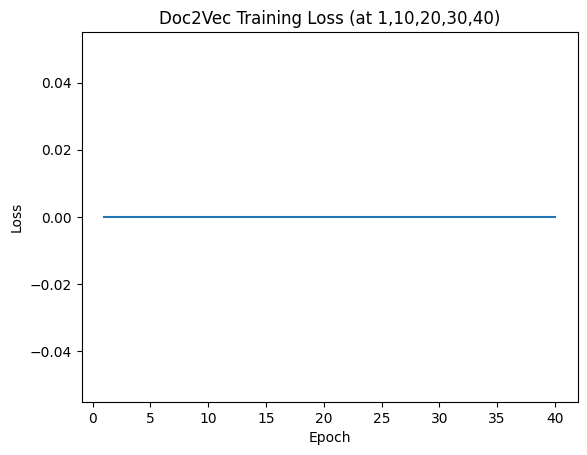

In [ ]:
# losses = []
# epochs_a_tracer = [1, 10, 20, 30, 40]

# for epoch in range(1, 41):  
#     doc2vec_modele.train(documents_tagges, total_examples=doc2vec_modele.corpus_count, epochs=1, compute_loss=True)#important car sinon on recalcule a chaque epoch et calcul loss 5 fois seulement
#     if epoch in epochs_a_tracer :
#         loss = doc2vec_modele.get_latest_training_loss()
#         losses.append(loss)
#         print(f"Epoch {epoch}, Loss: {loss}")

# plt.plot(epochs_a_tracer , losses)
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.title('Doc2Vec Training Loss (at 1,10,20,30,40)')
# plt.show()

"""Remarque : la  loss d'après mes recherches : https://stackoverflow.com/questions/56082233/gensim-doc2vec-how-to-get-the-value-of-loss-function-in-each-step n'existe pas 
c'est une abstraction implémentée pour word2vec mais probablement pas sur du doc2Vec ... problématiques d'héritage j'imagine """

In [16]:

documents_embeddings = [doc2vec_modele.dv[f'doc_{i}'] for i in range(len(PHRASES_DOCUMENT_NETTOYEES))]
X_doc2vec = np.array(documents_embeddings)

print(f"Shape Doc2Vec: {X_doc2vec.shape}")

Shape Doc2Vec: (38985, 300)


### chargement du modèle ou persistence
on persiste embeddings ici 


In [25]:
import datetime
save_modele = True ; date_jour = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")  

if save_modele : 
    np.save(f"models/embeddings_doc2vec_{doc2vec_modele.vector_size}_sans_doublons_{doc2vec_modele.epochs}_epochs_{doc2vec_modele.dm}_dmcbow_{date_jour}.npy", X_doc2vec)

X_doc2vec = np.load(f"models/embeddings_doc2vec_{doc2vec_modele.vector_size}_sans_doublons_{doc2vec_modele.epochs}_epochs_{doc2vec_modele.dm}_dmcbow_{date_jour}.npy")



### test similarités nouveau modele

In [61]:

def inference_doc2vec(doc: str , top_n = 10):
    """nécessite prétraitement en avance car prend des tokens en entrée d'un texte traitée"""
    tokens = preprocess_texte(doc).split()
    nouveau_vec = doc2vec_modele.infer_vector(tokens)
    # print("nouveau vec : ",nouveau_vec)
    similaires_inferes = doc2vec_modele.dv.most_similar([nouveau_vec], topn=top_n)
    liste_identifiants_docs = []
    print("Documents similaires au nouveau texte :")
    for doc_id, sim in similaires_inferes:
        print(f"{doc_id}: {sim:.3f}")
        document_contenu_categories = df.iloc[int(doc_id.split("_")[1]),1]
        document_contenu_title = df.iloc[int(doc_id.split("_")[1]),6]
        liste_identifiants_docs.append(int(doc_id.split("_")[1]))
        print(f"contenu du document associé : {document_contenu_categories}, \n {document_contenu_title}")

    return liste_identifiants_docs #pour l'instant
inference_doc2vec("physics quantum")

Documents similaires au nouveau texte :
doc_27182: 0.585
contenu du document associé : this paper has been withdrawn, 
 paper withdrawn
doc_18900: 0.483
contenu du document associé : The development of Graph Neural Networks (GNNs) has led to great progress in
machine learning on graph-structured data. These networks operate via diffusing
information across the graph nodes while capturing the structure of the graph.
Recently there has also seen tremendous progress in quantum computing
techniques. In this work, we explore applications of multi-particle quantum
walks on diffusing information across graphs. Our model is based on learning
the operators that govern the dynamics of quantum random walkers on graphs. We
demonstrate the effectiveness of our method on classification and regression
tasks., 
 development graph neural network gnns led great progress machine learning graphstructured data network operate via diffusing information across graph node capturing structure graph recently al

[27182, 18900, 12292, 38972, 20063, 6639, 34512, 10676, 29155, 2984]

In [ ]:
from collections import Counter
all_words = [word for doc in PHRASES_DOCUMENT_NETTOYEES for word in doc.split()]
word_freq = Counter(all_words)
print(word_freq.get('physic', 0), word_freq.get('network', 0))

323 41657


### remarque intéressante : 

bias énorme dans les données 323 41657 pour physic vs neural networks : 

post entrainement : inference_nouveau_document("physics quantum")

Documents similaires au nouveau texte :

doc_16717: 0.843
contenu du document associé : ['cs.CV', 'cs.CR'], 
 deep neural network achieved remarkable success computer vision natural language processing audio task

doc_33994: 0.731
contenu du document associé : ['cs.CV'], 
 participated task lesion segmentation paper describes algorithm final result validation set isic challenge skin lesion analysis towards melanoma detection

doc_27182: 0.721
contenu du document associé : ['cs.LG', 'stat.ML'], 
 paper withdrawn

doc_19332: 0.644
contenu du document associé : ['cs.LG', 'stat.ML'], 
 graph neural network gnns effective machine learning model various graph learning problem despite empirical success theoretical limitation gnns revealed recently consequently many gnn model proposed overcome limitation survey provide comprehensive overview expressive power gnns provably powerful varian


### Corriger le biais 

Les 40 identifiants CS sont :
cs.AI, cs.AR, cs.CC, cs.CE, cs.CG, cs.CL, cs.CR, cs.CV, cs.CY, cs.DB, cs.DC, cs.DL, cs.DM, cs.DS, cs.ET, cs.FL, cs.GL, cs.GR, cs.GT, cs.HC, cs.IR, cs.IT, cs.LG, cs.LO, cs.MA, cs.MM, cs.MS, cs.NA, cs.NE, cs.NI, cs.OH, cs.OS, cs.PF, cs.PL, cs.RO, cs.SC, cs.SD, cs.SE, cs.SI, cs.SY.
En très bref : cs.AI = IA générale, cs.CV = vision/pattern recognition, cs.CL = NLP, cs.LG = machine learning, cs.RO = robotique, cs.IR = recherche d’info, cs.CR = crypto/sécurité, cs.SE = génie logiciel, cs.DB = bases de données, cs.NI = réseaux, cs.DS = structures de données/algos, cs.LO = logique, cs.GT = game theory côté informatique, etc. cs.NA et cs.SY sont bien présents dans la taxonomie, mais comme alias seulement.


ON peut filtrer directement sur eux

## Modèle embedding document 2 :  On essaie de faire de la classification à partir des 20 catégories filtrées


on essaie de tester un modèle d'embeddings de scibert // allmini lm v6 si on a le temps dans un second temps 

In [56]:
from transformers import AutoTokenizer, AutoModel

nom_modele = "allenai/scibert_scivocab_uncased" #vocab meilleur et baseb https://github.com/allenai/scibert , modeles dispo sur huggings face
tokenizer = AutoTokenizer.from_pretrained(nom_modele)
modele_scibert = AutoModel.from_pretrained(nom_modele,use_safetensors = True) #forcer chargement poids di modele depuis safetensoers plus sécurisé que le pickle 

C:\Users\mokht\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [57]:
import torch

text = "This paper proposes a new method for image classification."

inputs = tokenizer(
    text,
    return_tensors="pt", 
    truncation=True,
    padding=True,
    max_length=128
)

with torch.no_grad():
    outputs = modele_scibert(**inputs)


print(outputs.last_hidden_state.shape)

torch.Size([1, 12, 768])


In [58]:
from torch.utils.data import DataLoader, Dataset
import torch

class ArxivDatasetPytorch(Dataset):
    #bénéficier du dataloader du moment qu'on déclare le __len__ , le __get_item__ , et 
    def __init__(self, texts, tokenizer, max_length=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        inputs = self.tokenizer(
            text,
            truncation=True,          
            padding='max_length',     
            max_length=self.max_length,
            return_tensors="pt"       
        )
        return {k: v.squeeze(0) for k, v in inputs.items()}

texts = df["summaries"] #brut car bert entrauiné sur text brut ...
batch_size = 32  
dataset = ArxivDatasetPytorch(texts, tokenizer, max_length=128) #pour l'instant 128 par longueur pris een compte
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

# embeddings = []
# modele_scibert.eval()
# with torch.no_grad(): #infrence
#     for batch in dataloader: #itérer sur el dataloader
#         outputs = modele_scibert(**batch)
#         masque_attention = batch['attention_mask'] 
#         masque_cache = outputs.last_hidden_state * masque_attention.unsqueeze(-1) #(batch, , hidden_size) * ((batch, seq_length, 1))
#         sentence_emb = masque_cache.sum(dim=1) / masque_attention.sum(dim=1, keepdim=True)#meilleur que la moyenne basique (somme sur la dimension de l'embedding sur la phrase pas le batch)
#         embeddings.append(sentence_emb)

# X_scibert = torch.cat(embeddings, dim=0).numpy()
# print(X_scibert.shape)

In [59]:
# np.save("models/embeddings_scibert.npy", X_scibert)
X_scibert = np.load("models/embeddings_scibert.npy")
X_scibert.shape

(38985, 768)

In [66]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np


def inference_scibert(texte : str , top_k=5):
    """entrée c'est le texte la sortie c'est les top 5 documents qui ressemblent le plus"""
    entrees = tokenizer(texte,truncation=True,padding='max_length',max_length=128,return_tensors="pt")
    with torch.no_grad():
        sorties = modele_scibert(**entrees)
        masque_attention = entrees['attention_mask']
        masque_cache = sorties.last_hidden_state * masque_attention.unsqueeze(-1)
        query_embedding = (masque_cache.sum(dim=1) / masque_attention.sum(dim=1, keepdim=True)).squeeze(0).numpy() #supprimer (1,768) 1 c'est le batch à enlever
    
    similarités = cosine_similarity([query_embedding], X_scibert)[0]
    
    top_indices_k = np.argsort(similarités)[::-1][:top_k]
    
    print(f"Recommandations pour : '{texte}'")
    for i, idx in enumerate(top_indices_k):
        print(f"element {i+1} / doc {idx} => Similarité: {similarités[idx]}")
        print(f"   Titre: {df.iloc[idx]['titles']}")
        print(f"   Résumé: {df.iloc[idx]['summaries'][:200]}... \n")
        print(f"   categories: {df.iloc[idx]['categories_a_garder']}... \n")
    
    return top_indices_k

scibert_liste = inference_scibert("deep learning for image classification",10)
doc2vec_liste = inference_doc2vec("deep learning for image classification",10)

print("liste scibert : ",scibert_liste)
print("liste doc2vec : ",doc2vec_liste)

Recommandations pour : 'deep learning for image classification'
element 1 / doc 4617 => Similarité: 0.7562457323074341
   Titre: Weakly Supervised Object Discovery by Generative Adversarial & Ranking Networks
   Résumé: The deep generative adversarial networks (GAN) recently have been shown to be
promising for different computer vision applications, like image edit- ing,
synthesizing high resolution images, generatin... 

   categories: ['cs.CV']... 

element 2 / doc 33352 => Similarité: 0.7528320550918579
   Titre: Generating Adversarial Perturbation with Root Mean Square Gradient
   Résumé: We focus our attention on the problem of generating adversarial perturbations
based on the gradient in image classification domain... 

   categories: ['cs.CV', 'cs.CR', 'cs.LG']... 

element 3 / doc 7788 => Similarité: 0.7527552247047424
   Titre: ConvNet Architecture Search for Spatiotemporal Feature Learning
   Résumé: Learning image representations with ConvNets by pre-training on ImageNet has

In [ ]:
from sklearn.metrics.pairwise import cosine_distances
from sklearn.decomposition import PCA


pca = PCA(n_components=100)
X_tfidf_pca = pca.fit_transform(liste_vectorizer_tf_idf.toarray())

dist_scibert = cosine_distances(X_scibert)
dist_doc2vec = cosine_distances(X_doc2vec)
dist_tfidf = cosine_distances(X_tfidf_pca)

views = [dist_scibert, dist_doc2vec, dist_tfidf]